# Negotiation analysis: OPM sensitivity (Table 2), Campylobacter adaptation, Fig. 4

Upload to `/content`: `table2_proportional_floor.py`,
`negotiation_sensitivity_core_promptzip.py`, `campy_nbs_strategy_search.py`,
`Case2_OPM_Workshop_Alex_final_scores.csv`,
`Case1_Campy_Workshop_Alex_final_scores.csv`, `OPM_thoughts.zip`.


## 0. Environment

In [2]:
import os
need = ["table2_proportional_floor.py", "negotiation_sensitivity_core_promptzip.py",
        "campy_nbs_strategy_search.py", "Case2_OPM_Workshop_Alex_final_scores.csv",
        "Case1_Campy_Workshop_Alex_final_scores.csv", "OPM_thoughts.zip"]
for f in need:
    print(("OK   " if os.path.exists("/content/" + f) else "MISSING "), f)

OK    table2_proportional_floor.py
OK    negotiation_sensitivity_core_promptzip.py
OK    campy_nbs_strategy_search.py
OK    Case2_OPM_Workshop_Alex_final_scores.csv
OK    Case1_Campy_Workshop_Alex_final_scores.csv
OK    OPM_thoughts.zip


In [3]:
# LaTeX is needed only for the Table 2 PDF; the .tex and all CSVs are written regardless.
!apt-get -qq install texlive-latex-base texlive-latex-recommended texlive-fonts-recommended > /dev/null
!pdflatex --version | head -1

pdfTeX 3.141592653-2.6-1.40.25 (TeX Live 2023/Debian)


## 1. OPM sensitivity analysis (Table 2)

Per-issue tolerance `max(1 point, 25% of the issue weight)`, budget preserved,
shared acceptance threshold `65 +/- 10%`, uniform hit-and-run. Deals are taken
from the public `answers*.json` files, counting every distinct deal in each
final proposal.

In [4]:
!python "/content/table2_proportional_floor.py" \
  --scores-csv "/content/Case2_OPM_Workshop_Alex_final_scores.csv" \
  --separator ";" \
  --threshold 65 \
  --llm-logs-zip "/content/OPM_thoughts.zip" \
  --top-k 7 \
  --logs-source answers \
  --deal-selection all \
  --frac 0.25 \
  --floor-pts 1.0 \
  --zero-upper 1.0 \
  --threshold-frac 0.10 \
  --threshold-mode common \
  --mc-samples 10000 \
  --burn-in 500 \
  --thinning 100 \
  --seed 123 \
  --out "/content/table2_opm"

Issue-weight totals per stakeholder: {'Municipalities and Local Governments': 100.0, 'Public Health Authorities': 100.0, 'Forestry Services and Landowners': 100.0, 'Environmental NGOs': 100.0, 'General Public and Community Groups': 100.0}
Parsed 35 answers files from the logs zip; none contained private reasoning
Extracted 39 deals from 35 runs (4 runs proposed a fallback in addition to a primary deal)
[MC] 100/10000
[MC] 200/10000
[MC] 300/10000
[MC] 400/10000
[MC] 500/10000
[MC] 600/10000
[MC] 700/10000
[MC] 800/10000
[MC] 900/10000
[MC] 1000/10000
[MC] 1100/10000
[MC] 1200/10000
[MC] 1300/10000
[MC] 1400/10000
[MC] 1500/10000
[MC] 1600/10000
[MC] 1700/10000
[MC] 1800/10000
[MC] 1900/10000
[MC] 2000/10000
[MC] 2100/10000
[MC] 2200/10000
[MC] 2300/10000
[MC] 2400/10000
[MC] 2500/10000
[MC] 2600/10000
[MC] 2700/10000
[MC] 2800/10000
[MC] 2900/10000
[MC] 3000/10000
[MC] 3100/10000
[MC] 3200/10000
[MC] 3300/10000
[MC] 3400/10000
[MC] 3500/10000
[MC] 3600/10000
[MC] 3700/10000
[MC] 3800/1

In [5]:
import pandas as pd
print(pd.read_csv("/content/table2_opm/Table2_values.csv")[
    ["ID", "Deal", "Runs", "IRpct", "ParetoPct", "Hmed", "L1med", "L2med", "Lossmed"]
].to_string(index=False))
print()
print(pd.read_csv("/content/table2_opm/alternative_NBS_distribution.csv").head(8).to_string(index=False))

ID              Deal  Runs  IRpct  ParetoPct  Hmed      L1med     L2med   Lossmed
N0 A3,B2,C3,D1,E1,F2     0  92.23      100.0   2.0  22.736959 12.646800 15.216229
R1 A3,B2,C3,D1,E2,F1     5  34.56      100.0   3.0  41.959622 22.004540 76.201109
R2 A3,B2,C3,D1,E2,F2     3   4.70      100.0   3.0  44.565644 23.992949 88.050017
R3 A3,B2,C3,D1,E2,F3     3  55.21      100.0   3.0  45.067875 24.284140 85.929437
R4 A3,B3,C2,D2,E3,F1     3   0.00      100.0   4.0 100.694909 48.939266       NaN
R5 A2,B2,C2,D1,E2,F2     2   0.00        0.0   4.0  61.370928 37.909173       NaN
R6 A3,B2,C3,D1,E3,F3     2  76.10      100.0   3.0  41.179413 22.036101 81.039534
R7 A4,B2,C3,D1,E2,F3     2   0.00      100.0   3.0  79.982279 42.905755       NaN

             Deal  Count       Pct  H_vs_N0
A3,B2,C3,D1,E1,F2   2499 24.992499        0
A4,B2,C3,D2,E3,F2   1862 18.621862        3
A3,B2,C3,D2,E1,F3   1614 16.141614        2
A3,B2,C3,D2,E1,F2   1061 10.611061        1
A4,B2,C3,D2,E3,F1    908  9.080908       

## 2. Campylobacter adaptation / threshold grid

Same weight-perturbation conventions. `--disagreement-point` is omitted so each
test uses its own acceptance threshold as the no-agreement payoff. Slow cell:
seven tests of 100,000 hit-and-run draws.

In [6]:
!python "/content/campy_nbs_strategy_search.py" \
  "/content/Case1_Campy_Workshop_Alex_final_scores.csv" \
  --threshold 65 \
  --weight-floor 1.0 \
  --caps "0.25" \
  --threshold-variation 0.10 \
  --uniform-tests "0.25:0.10" \
  --fixed-tests "0.25:65,0.25:63.75,0.25:62.5,0.25:61.25,0.25:60,0.25:57.5" \
  --samples 100000 \
  --conditional-samples 2000 \
  --burn-in 500 \
  --thinning 5 \
  --output-dir "/content/campy_nbs_grid"

{
  "baseline": {
    "stakeholders": [
      "Food Safety Authorities",
      "Food industry",
      "Consumers",
      "Environmental NGOs"
    ],
    "issues": [
      "A",
      "B",
      "C",
      "D",
      "E"
    ],
    "number_of_packages": 1200,
    "issue_weights": {
      "Food Safety Authorities": {
        "A": 40.0,
        "B": 20.0,
        "C": 10.0,
        "D": 20.0,
        "E": 10.0
      },
      "Food industry": {
        "A": 30.0,
        "B": 10.0,
        "C": 30.0,
        "D": 10.0,
        "E": 20.0
      },
      "Consumers": {
        "A": 30.0,
        "B": 20.0,
        "C": 30.0,
        "D": 10.0,
        "E": 10.0
      },
      "Environmental NGOs": {
        "A": 20.0,
        "B": 40.0,
        "C": 15.0,
        "D": 0.0,
        "E": 25.0
      }
    },
    "threshold": 65.0,
    "disagreement_point": 65.0,
    "feasible_package_count": 0,
    "infeasibility_gap": 10.0,
    "closest_to_feasible_package": "A3,B3,C4,D2,E2",
    "binding_stakeh

In [7]:
import pandas as pd, json
u = pd.read_csv("/content/campy_nbs_grid/unconditional_mc_summary.csv")
print(u[["threshold_center", "threshold_relative_variation",
         "iterations_with_any_feasible_package", "samples",
         "maximum_feasible_package_count_in_one_iteration"]].to_string(index=False))
print()
print(pd.read_csv("/content/campy_nbs_grid/conditional_nbs_summary.csv")[
    ["conditioning_package", "threshold", "samples", "nbs_counts_json"]].to_string(index=False))
b = json.load(open("/content/campy_nbs_grid/campy_nbs_strategy_results.json"))["baseline"]
print()
print("feasible at 65:", b["feasible_package_count"],
      "| infeasibility gap:", b["infeasibility_gap"],
      "| binding:", b["binding_stakeholders"])

 threshold_center  threshold_relative_variation  iterations_with_any_feasible_package  samples  maximum_feasible_package_count_in_one_iteration
            65.00                           0.1                                  1562   100000                                                3
            65.00                           0.0                                     1   100000                                                1
            63.75                           0.0                                    30   100000                                                1
            62.50                           0.0                                   347   100000                                                2
            61.25                           0.0                                  1554   100000                                                2
            60.00                           0.0                                  5176   100000                                          

### 2b. Visualize the grid search

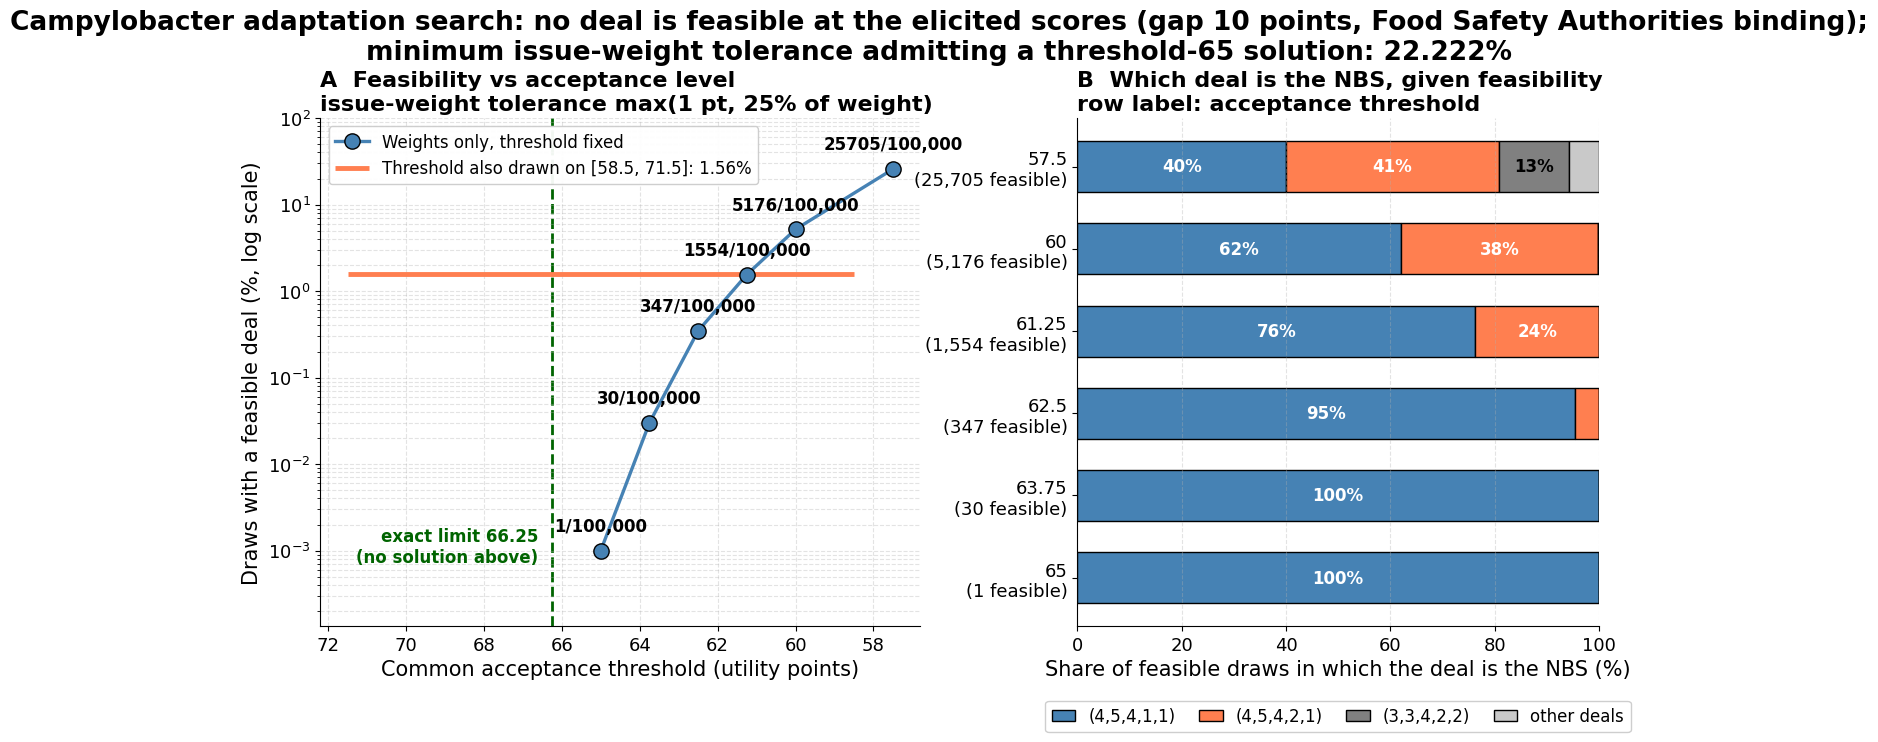

Saved /content/campy_nbs_grid/Fig_adaptation_grid.png and .pdf


In [8]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

GRID_DIR = "/content/campy_nbs_grid"
FIG_OUT = f"{GRID_DIR}/Fig_adaptation_grid.png"

plt.rcParams["font.family"] = "sans-serif"
FS = dict(title=19, sub=16, lab=15, tick=13, ann=12, leg=12)

res = json.load(open(f"{GRID_DIR}/campy_nbs_strategy_results.json"))
mc = pd.read_csv(f"{GRID_DIR}/unconditional_mc_summary.csv")
front = pd.read_csv(f"{GRID_DIR}/exact_feasibility_frontier.csv")
base = res["baseline"]
crit = res["critical_issue_cap_at_central_threshold"]

fixed = (mc[mc["threshold_relative_variation"] == 0]
         .sort_values("threshold_center").reset_index(drop=True))
varying = mc[mc["threshold_relative_variation"] > 0]

cap = float(fixed["relative_cap"].iloc[0])
attainable = float(front["Highest_attainable_common_threshold"].iloc[0])
gap = float(base["infeasibility_gap"])
n = int(fixed["samples"].iloc[0])

fig, (axA, axB) = plt.subplots(1, 2, figsize=(16.5, 6.6),
                               gridspec_kw={"width_ratios": [1.15, 1.0], "wspace": 0.28})

# -------------------------------------------------- A: feasibility vs threshold
x = fixed["threshold_center"].to_numpy(float)
hits = fixed["iterations_with_any_feasible_package"].to_numpy(float)
rate = 100.0 * hits / n
floor = 100.0 / n / 3.0                      # plotting floor for zero-hit rows
yplot = np.where(hits > 0, rate, floor)

axA.plot(x, yplot, "-o", color="steelblue", linewidth=2.4, markersize=11,
         markeredgecolor="black", zorder=3, label="Weights only, threshold fixed")
for xi, yi, h in zip(x, yplot, hits):
    axA.annotate(f"{int(h)}/{n:,}", (xi, yi), textcoords="offset points",
                 xytext=(0, 14), ha="center", fontsize=FS["ann"], fontweight="bold")

if len(varying):
    vr = 100.0 * float(varying["probability_any_feasible_package"].iloc[0])
    lo, hi = [float(v) for v in str(varying["threshold_interval"].iloc[0]).strip("[]()").split(",")]
    axA.hlines(vr, lo, hi, color="coral", linewidth=3.5, zorder=2,
               label=f"Threshold also drawn on [{lo:g}, {hi:g}]: {vr:.2f}%")

axA.axvline(attainable, color="darkgreen", linestyle="--", linewidth=2, zorder=1)
axA.annotate(f"exact limit {attainable:g}\n(no solution above)", (attainable, floor * 2.2),
             xytext=(-10, 0), textcoords="offset points", ha="right",
             fontsize=FS["ann"], color="darkgreen", fontweight="bold")

axA.set_yscale("log")
axA.set_xlabel("Common acceptance threshold (utility points)", fontsize=FS["lab"])
axA.set_ylabel(f"Draws with a feasible deal (%, log scale)", fontsize=FS["lab"])
axA.set_title(f"A  Feasibility vs acceptance level\n"
              f"issue-weight tolerance max(1 pt, {cap*100:g}% of weight)",
              fontsize=FS["sub"], fontweight="bold", loc="left")
axA.set_ylim(floor / 2.5, 100)
axA.invert_xaxis()
axA.grid(alpha=0.35, linestyle="--", which="both")
axA.tick_params(labelsize=FS["tick"])
axA.legend(fontsize=FS["leg"], loc="upper left", framealpha=0.95)

# -------------------------------------------------- B: which deal is the NBS
comp = {}
for _, r in fixed.iterrows():
    comp[float(r["threshold_center"])] = json.loads(r["nbs_counts_json"] or "{}")
totals = {t: sum(c.values()) for t, c in comp.items()}
overall = pd.Series({d: sum(c.get(d, 0) for c in comp.values())
                     for d in {k for c in comp.values() for k in c}}).sort_values(ascending=False)
top = list(overall.index[:3])
short = lambda d: "(" + ",".join(p[1:] for p in d.split(",")) + ")"
colors = ["steelblue", "coral", "grey", "#c9c9c9"]

ys = sorted(comp, reverse=True)
ypos = np.arange(len(ys))
left = np.zeros(len(ys))
for k, deal in enumerate(top + ["other"]):
    vals = []
    for t in ys:
        tot = totals[t]
        if tot == 0:
            vals.append(0.0)
        elif deal == "other":
            vals.append(100.0 * (tot - sum(comp[t].get(d, 0) for d in top)) / tot)
        else:
            vals.append(100.0 * comp[t].get(deal, 0) / tot)
    vals = np.array(vals)
    axB.barh(ypos, vals, left=left, height=0.62, color=colors[k],
             edgecolor="black", linewidth=1.0,
             label=short(deal) if deal != "other" else "other deals")
    for i, v in enumerate(vals):
        if v >= 9:
            axB.text(left[i] + v / 2, ypos[i], f"{v:.0f}%", ha="center", va="center",
                     fontsize=FS["ann"], fontweight="bold",
                     color="white" if k < 2 else "black")
    left += vals

axB.set_yticks(ypos)
axB.set_yticklabels([f"{t:g}\n({totals[t]:,} feasible)" for t in ys], fontsize=FS["tick"])
axB.set_xlabel("Share of feasible draws in which the deal is the NBS (%)", fontsize=FS["lab"])
axB.set_title("B  Which deal is the NBS, given feasibility\nrow label: acceptance threshold",
              fontsize=FS["sub"], fontweight="bold", loc="left")
axB.set_xlim(0, 100)
axB.grid(axis="x", alpha=0.35, linestyle="--")
axB.tick_params(axis="x", labelsize=FS["tick"])
axB.legend(fontsize=FS["leg"], loc="upper center", bbox_to_anchor=(0.5, -0.13),
           ncol=4, framealpha=0.95, columnspacing=1.4, handlelength=1.4)
for s in ("top", "right"):
    axB.spines[s].set_visible(False)
    axA.spines[s].set_visible(False)

fig.suptitle(
    f"Campylobacter adaptation search: no deal is feasible at the elicited scores "
    f"(gap {gap:g} points, {', '.join(base['binding_stakeholders'])} binding);\n"
    f"minimum issue-weight tolerance admitting a threshold-65 solution: "
    f"{crit['critical_cap']*100:.3f}%",
    fontsize=FS["title"], fontweight="bold", y=1.045)

fig.savefig(FIG_OUT, dpi=200, bbox_inches="tight")
fig.savefig(FIG_OUT.replace(".png", ".pdf"), bbox_inches="tight")
plt.show()
print(f"Saved {FIG_OUT} and .pdf")

## 3. Fig. 4 — equilibrium characterization (65 as baseline)

Unperturbed scores. The deal list now comes from
`Results_extracted_all_deals.csv` produced in section 1, so counts match the
`Runs` column of Table 2. Switch `DEALS_FILE` to
`Results_extracted_primary_only.csv` to count one deal per run.

In [9]:
import itertools
import math

import numpy as np
import pandas as pd

SCORES_FILE = "/content/Case2_OPM_Workshop_Alex_final_scores.csv"
DEALS_FILE = "/content/table2_opm/Results_extracted_all_deals.csv"  # or Results_extracted_primary_only.csv
SEPARATOR = ";"
DISAGREEMENT = 65
EXPORT = "/content/table2_opm/Fig4_deal_metrics.csv"

pref_df = pd.read_csv(SCORES_FILE, sep=SEPARATOR)
res_df = pd.read_csv(DEALS_FILE, sep=SEPARATOR)

stakeholders = pref_df["Stakeholder"].astype(str).tolist()
disagreement = {sh: DISAGREEMENT for sh in stakeholders}

issues, options_per_issue, pref = [], {}, {sh: {} for sh in stakeholders}
for col in pref_df.columns[1:]:
    issue, option = col[0], int(col[1:])
    if issue not in options_per_issue:
        issues.append(issue)
        options_per_issue[issue] = []
    options_per_issue[issue].append(option)
    for _, row in pref_df.iterrows():
        sh = str(row["Stakeholder"])
        pref[sh].setdefault(issue, {})[option] = float(row[col])
for issue in issues:
    options_per_issue[issue] = sorted(options_per_issue[issue])

all_packages = list(itertools.product(*[options_per_issue[i] for i in issues]))

packages_data = []
for pkg in all_packages:
    utils = tuple(sum(pref[sh][issues[i]][pkg[i]] for i in range(len(issues)))
                  for sh in stakeholders)
    gains = tuple(utils[i] - disagreement[stakeholders[i]] for i in range(len(stakeholders)))
    is_ir = all(g >= 0 for g in gains)
    nash = float(np.prod(gains)) if is_ir else None
    packages_data.append({"Package": pkg, "Utilities": utils, "Disagreement_Gains": gains,
                          "Is_Individually_Rational": is_ir, "Nash_Product": nash})

# NBS over individually rational packages; ties broken by total welfare, as in
# choose_nbs_fast of the Table 2 script, so both report the same benchmark.
ir_packages = [p for p in packages_data if p["Is_Individually_Rational"]]
nbs_package, max_nash = None, None
if ir_packages:
    max_nash = max(p["Nash_Product"] for p in ir_packages)
    tied = [p for p in ir_packages if p["Nash_Product"] == max_nash]
    nbs_package = max(tied, key=lambda p: sum(p["Utilities"]))
    if len(tied) > 1:
        print(f"NOTE: {len(tied)} packages tie on the Nash product; broken by total welfare")
    if max_nash <= 0:
        print("WARNING: the maximal Nash product is 0; at least one stakeholder sits "
              "exactly on the disagreement point, so the benchmark is degenerate")
else:
    gaps = [max(disagreement[stakeholders[i]] - p["Utilities"][i]
                for i in range(len(stakeholders))) for p in packages_data]
    j = int(np.argmin(gaps))
    print(f"No individually rational package exists; no NBS. Infeasibility gap "
          f"{gaps[j]:.1f} utility points at {packages_data[j]['Package']}")

pareto_front = []
for pkg1 in packages_data:
    u1 = pkg1["Utilities"]
    if any(all(f >= x for f, x in zip(pf["Utilities"], u1))
           and any(f > x for f, x in zip(pf["Utilities"], u1)) for pf in pareto_front):
        continue
    pareto_front = [pf for pf in pareto_front
                    if not (all(x >= f for x, f in zip(u1, pf["Utilities"]))
                            and any(x > f for x, f in zip(u1, pf["Utilities"])))]
    pareto_front.append(pkg1)
pareto_packages_set = {p["Package"] for p in pareto_front}

print(f"{len(all_packages)} packages | {len(pareto_front)} Pareto optimal | "
      f"{len(ir_packages)} individually rational")
if nbs_package:
    print(f"NBS {nbs_package['Package']} utilities {nbs_package['Utilities']} "
          f"Nash product {max_nash:,.0f}")

by_package = {p["Package"]: p for p in packages_data}
rows = []
for _, row in res_df.iterrows():
    pkg = tuple(int(row[i]) for i in issues)
    info = by_package.get(pkg)
    if info is None:
        print(f"WARNING: deal {pkg} in round {row['Round']} is not a valid package")
        continue
    rec = {"Round": row["Round"], "Package": pkg, "Utilities": info["Utilities"],
           "Is_Individually_Rational": info["Is_Individually_Rational"],
           "Nash_Product": info["Nash_Product"],
           "Is_Pareto_Optimal": pkg in pareto_packages_set}
    if nbs_package is not None:
        d = [nbs_package["Utilities"][i] - info["Utilities"][i] for i in range(len(stakeholders))]
        rec.update({
            "Is_NBS": pkg == nbs_package["Package"],
            "Hamming_to_NBS": sum(a != b for a, b in zip(pkg, nbs_package["Package"])),
            "Manhattan_to_NBS": sum(abs(x) for x in d),
            "Euclidean_to_NBS": math.sqrt(sum(x * x for x in d)),
            "Nash_Loss_Pct": (abs((info["Nash_Product"] - max_nash) / max_nash) * 100
                              if info["Is_Individually_Rational"] and max_nash else np.nan),
        })
    rows.append(rec)

res_analysis_df = pd.DataFrame(rows)
res_analysis_df.to_csv(EXPORT, index=False)
n = len(res_analysis_df)
print(f"\n{n} deals across {res_analysis_df['Round'].nunique()} rounds | "
      f"Pareto {res_analysis_df['Is_Pareto_Optimal'].sum()} "
      f"({res_analysis_df['Is_Pareto_Optimal'].mean()*100:.1f}%) | "
      f"IR {res_analysis_df['Is_Individually_Rational'].sum()} "
      f"({res_analysis_df['Is_Individually_Rational'].mean()*100:.1f}%)")

11250 packages | 194 Pareto optimal | 75 individually rational
NBS (3, 2, 3, 1, 1, 2) utilities (75.0, 85.0, 83.0, 71.0, 83.0) Nash product 388,800

39 deals across 35 rounds | Pareto 28 (71.8%) | IR 10 (25.6%)


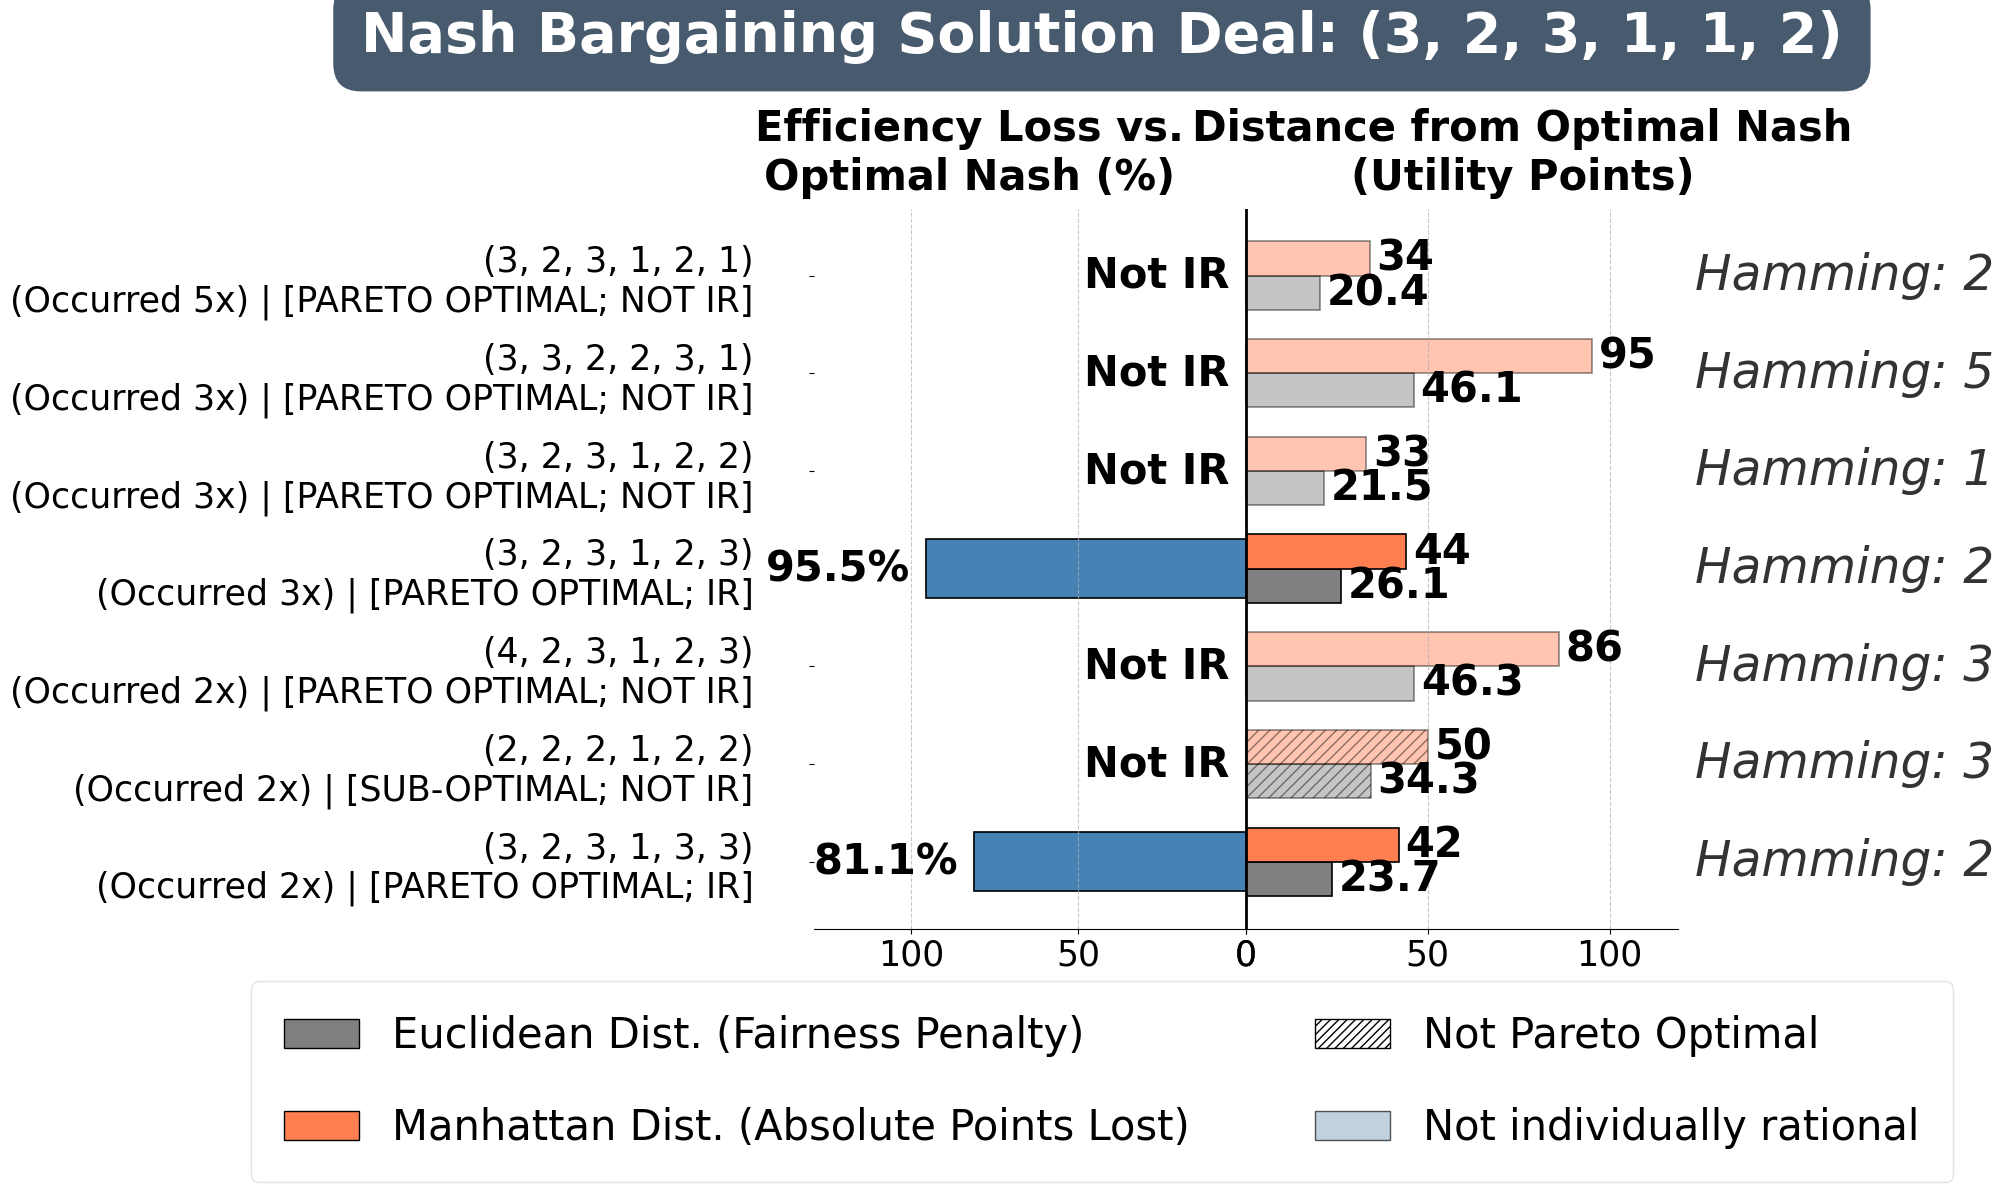

Saved /content/table2_opm/Fig_4.png and .pdf
           Package  Count Loss_Label  Hamming  Euclidean  Manhattan  Is_Pareto  Is_IR
(3, 2, 3, 1, 3, 3)      2      81.1%        2  23.664319       42.0       True   True
(2, 2, 2, 1, 2, 2)      2     Not IR        3  34.263683       50.0      False  False
(4, 2, 3, 1, 2, 3)      2     Not IR        3  46.281746       86.0       True  False
(3, 2, 3, 1, 2, 3)      3      95.5%        2  26.076810       44.0       True   True
(3, 2, 3, 1, 2, 2)      3     Not IR        1  21.517435       33.0       True  False
(3, 3, 2, 2, 3, 1)      3     Not IR        5  46.076024       95.0       True  False
(3, 2, 3, 1, 2, 1)      5     Not IR        2  20.445048       34.0       True  False


In [10]:
FS = dict(sub=30, tick=25, bar=30, ham=35, badge=40, leg=30)
plt.rcParams["font.family"] = "sans-serif"
fmt_num = lambda x: f"{x:.1f}".rstrip("0").rstrip(".")

counts = res_analysis_df["Package"].value_counts()
deal_counts = counts[counts > 1]
if nbs_package is None or len(deal_counts) == 0:
    raise SystemExit("Nothing to plot")

top = []
for pkg, count in deal_counts.items():
    info = by_package[pkg]
    is_ir = info["Is_Individually_Rational"]
    loss = (abs((info["Nash_Product"] - max_nash) / max_nash) * 100
            if is_ir and max_nash else np.nan)
    d = [nbs_package["Utilities"][i] - info["Utilities"][i] for i in range(len(stakeholders))]
    top.append({"Package": str(pkg), "Count": count, "Loss_Pct": loss,
                "Loss_For_Plot": 0.0 if np.isnan(loss) else loss,
                "Loss_Label": "Not IR" if np.isnan(loss) else f"{loss:.1f}%",
                "Is_Pareto": pkg in pareto_packages_set, "Is_IR": is_ir,
                "Hamming": sum(a != b for a, b in zip(pkg, nbs_package["Package"])),
                "Euclidean": math.sqrt(sum(x * x for x in d)),
                "Manhattan": sum(abs(x) for x in d)})
df = (pd.DataFrame(top)
      .sort_values(["Count", "Loss_For_Plot", "Package"], ascending=[True, False, True])
      .reset_index(drop=True))

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.transforms import blended_transform_factory

FIG_OUT = "/content/table2_opm/Fig_4.png"

H = 3.8 + len(df) * 1.05
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, H),
                               sharey=True, gridspec_kw={"wspace": 0.0})
y = np.arange(len(df))
bh, c_loss, c_euc, c_man, c_nir = 0.35, "steelblue", "grey", "coral", "#9ebbd0"

max_loss = max(df["Loss_Pct"].dropna().max() if df["Loss_Pct"].notna().any() else 1.0, 1.0)
bars1 = ax1.barh(y, df["Loss_For_Plot"], height=0.6, color=c_loss,
                 edgecolor="black", linewidth=1.2)
ax1.axvline(0, color="black", linewidth=2)
for i, bar in enumerate(bars1):
    lab = df.loc[i, "Loss_Label"]
    x = max_loss * 0.05 if lab == "Not IR" else bar.get_width() + max_loss * 0.05
    ax1.text(x, bar.get_y() + bar.get_height() / 2, lab, va="center", ha="right",
             fontsize=FS["bar"], fontweight="bold")
ax1.set_title("Efficiency Loss vs.\nOptimal Nash (%)", x=0.36, pad=14,
              fontsize=FS["sub"], fontweight="bold")
ax1.set_xlim(max_loss * 1.35, 0)
ax1.grid(axis="x", linestyle="--", alpha=0.7)
ax1.tick_params(axis="x", labelsize=FS["tick"])

max_dist = max(df["Euclidean"].max(), df["Manhattan"].max(), 1.0)
b_euc = ax2.barh(y - bh / 2, df["Euclidean"], height=bh, color=c_euc,
                 edgecolor="black", linewidth=1.2)
b_man = ax2.barh(y + bh / 2, df["Manhattan"], height=bh, color=c_man,
                 edgecolor="black", linewidth=1.2)
ax2.axvline(0, color="black", linewidth=2)
tr = blended_transform_factory(ax2.transAxes, ax2.transData)
for i, (e, m, h) in enumerate(zip(df["Euclidean"], df["Manhattan"], df["Hamming"])):
    ax2.text(e + max_dist * 0.02, y[i] - bh / 2, fmt_num(e), va="center", ha="left",
             fontsize=FS["bar"], fontweight="bold")
    ax2.text(m + max_dist * 0.02, y[i] + bh / 2, fmt_num(m), va="center", ha="left",
             fontsize=FS["bar"], fontweight="bold")
    ax2.text(1.04, y[i], f"Hamming: {h}", transform=tr, va="center", ha="left",
             color="#333333", fontsize=FS["ham"], fontstyle="italic", clip_on=False,
             bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.5))
ax2.set_title("Distance from Optimal Nash\n(Utility Points)", x=0.64, pad=14,
              fontsize=FS["sub"], fontweight="bold")
ax2.set_xlim(0, max_dist * 1.25)
ax2.grid(axis="x", linestyle="--", alpha=0.7)
ax2.tick_params(axis="x", labelsize=FS["tick"])

for i, row in df.iterrows():
    if not row["Is_Pareto"]:
        for b in (bars1[i], b_euc[i], b_man[i]):
            b.set_hatch("///")
    if not row["Is_IR"]:
        bars1[i].set_facecolor(c_nir)
        bars1[i].set_alpha(0.65)
        b_euc[i].set_alpha(0.45)
        b_man[i].set_alpha(0.45)

ax1.set_yticks(y)
ax1.set_yticklabels(
    [f"{r['Package']}\n(Occurred {r['Count']}x) | "
     f"[{'PARETO OPTIMAL' if r['Is_Pareto'] else 'SUB-OPTIMAL'}; "
     f"{'IR' if r['Is_IR'] else 'NOT IR'}]" for _, r in df.iterrows()],
    fontsize=FS["tick"])
ax1.tick_params(axis="y", pad=40)
plt.setp(ax1.get_yticklabels(), ha="right")
ax2.tick_params(axis="y", left=False, labelleft=False)
for ax in (ax1, ax2):
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)

legend = fig.legend(handles=[
    mpatches.Patch(facecolor=c_euc, edgecolor="black", label="Euclidean Dist. (Fairness Penalty)"),
    mpatches.Patch(facecolor=c_man, edgecolor="black", label="Manhattan Dist. (Absolute Points Lost)"),
    mpatches.Patch(facecolor="white", edgecolor="black", hatch="////", label="Not Pareto Optimal"),
    mpatches.Patch(facecolor=c_nir, edgecolor="black", alpha=0.65, label="Not individually rational"),
], loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.08), fontsize=FS["leg"],
    frameon=True, columnspacing=3.0, handlelength=1.8, handletextpad=0.8,
    borderpad=0.8, labelspacing=1.2)
legend.get_frame().set_edgecolor("#dddddd")
legend.get_frame().set_facecolor("white")

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
fig.subplots_adjust(left=0.34, right=0.82, bottom=1.85 / H, top=1 - 2.1 / H)
fig.text(0.5, 1 - 0.38 / H, f"Nash Bargaining Solution Deal: {nbs_package['Package']}",
         ha="center", va="center", fontsize=FS["badge"], fontweight="bold", color="white",
         bbox=dict(facecolor="#34495e", edgecolor="none", boxstyle="round,pad=0.5", alpha=0.9))
fig.savefig(FIG_OUT, dpi=200, bbox_inches="tight")
fig.savefig(FIG_OUT.replace(".png", ".pdf"), bbox_inches="tight")
plt.show()
print(f"Saved {FIG_OUT} and .pdf")
print(df[["Package", "Count", "Loss_Label", "Hamming", "Euclidean", "Manhattan",
          "Is_Pareto", "Is_IR"]].to_string(index=False))

## 4. Notes

- Table 2's `IR in MC` is the share of *perturbed* draws in which a deal is
  individually rational; Fig. 4's `IR` label is the *unperturbed* status at
  threshold 65. A deal can be NOT IR in Fig. 4 and IR in a fraction of Table 2
  draws.
- The NBS in Fig. 4 must equal `N0` in Table 2: `(3,2,3,1,1,2)`, utilities
  `(75, 85, 83, 71, 83)`, Nash product 388,800. Both break Nash-product ties by
  total welfare.
- `Fig4_deal_metrics.csv` holds per-round Hamming, Manhattan, Euclidean and
  Nash-loss values. The separate gain-space Manhattan column of the original
  script was dropped: with a common disagreement point it is identically equal
  to the utility-space Manhattan distance.

## 5. Workflow schemas

rendered both schemas


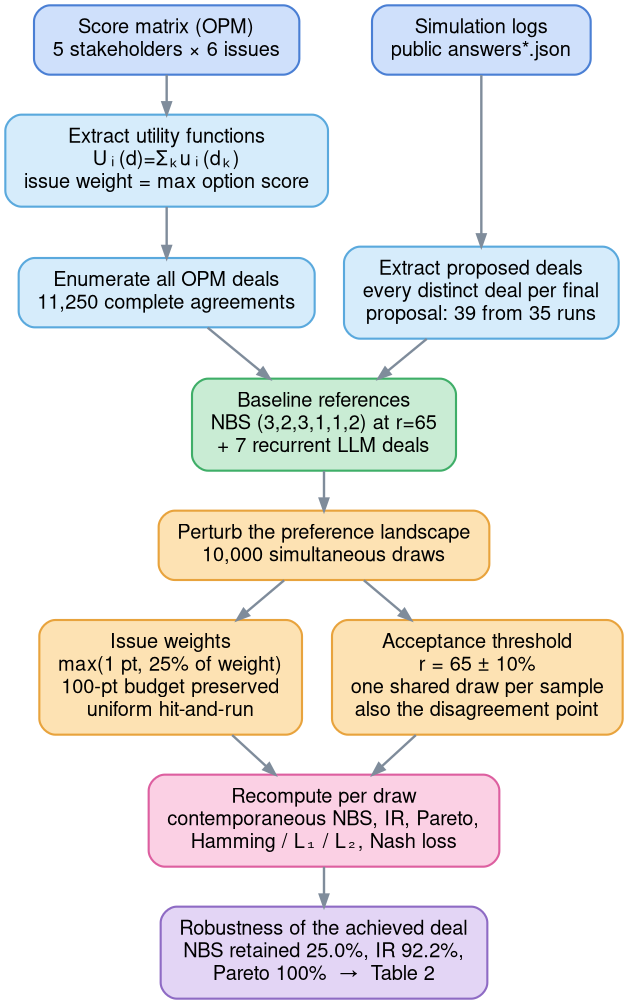

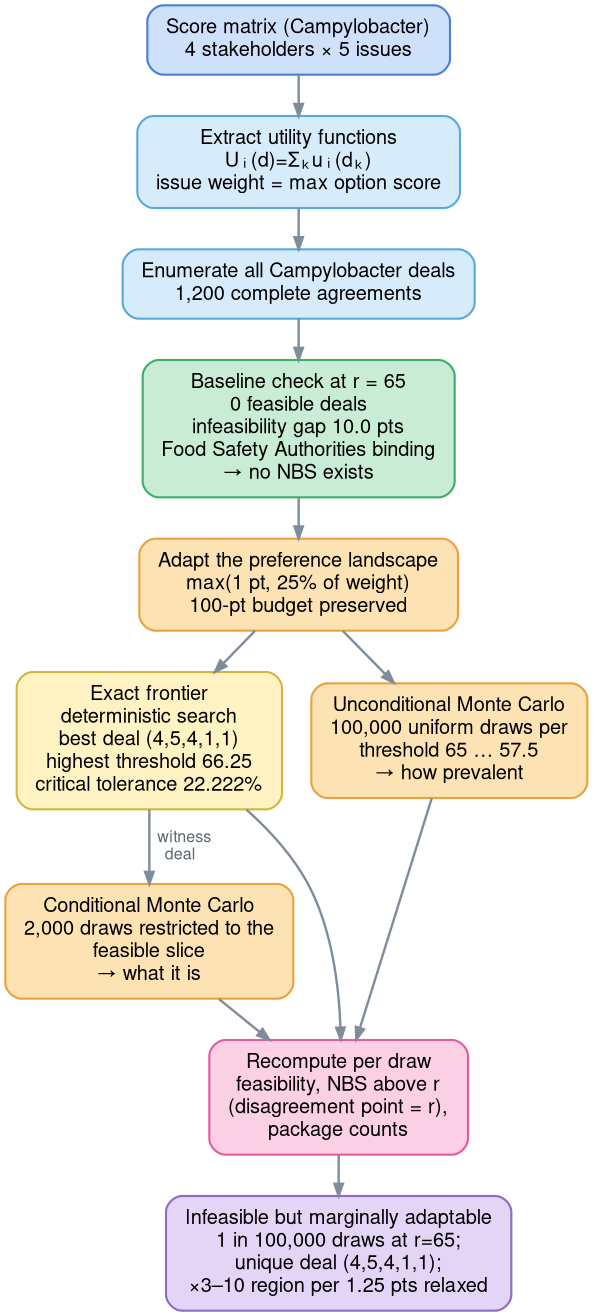

In [11]:
# Workflow schemas. In Colab run first: !apt-get -qq install graphviz > /dev/null
#                                       !pip -q install graphviz
"""Flowchart schemas for the sensitivity (OPM) and adaptation (Campylobacter) analyses."""
from graphviz import Digraph

OUT_DIR = "/content"

FILL = {
    "input": "#cfe0fb",      # source data
    "derive": "#d6ecfb",     # deterministic derivation
    "base": "#c9ecd4",       # baseline references
    "perturb": "#fde2b3",    # perturbation
    "exact": "#fff3c4",      # exact / deterministic search
    "metric": "#fbd0e4",     # recomputed metrics
    "result": "#e3d5f5",     # interpretation
}
EDGE = {"#7f8c9b"}


def new_graph(name):
    g = Digraph(name, format="png")
    g.attr(rankdir="TB", bgcolor="white", splines="spline", nodesep="0.30", ranksep="0.42")
    g.attr("node", shape="box", style="rounded,filled", fontname="DejaVu Sans",
           fontsize="15", penwidth="1.6", margin="0.20,0.12", height="0.1")
    g.attr("edge", color="#7f8c9b", penwidth="1.8", arrowsize="0.9",
       fontname="DejaVu Sans", fontsize="12", fontcolor="#5b6770")
    return g


def node(g, key, label, kind, color=None):
    edge_col = {"input": "#4a7fd4", "derive": "#5aa9dd", "base": "#3fae68",
                "perturb": "#e8a33d", "exact": "#d4b73a", "metric": "#dd5fa0",
                "result": "#8e6bc4"}[kind]
    g.node(key, label, fillcolor=FILL[kind], color=color or edge_col)


# ==================================================================== SENSITIVITY
s = new_graph("sensitivity_opm")
node(s, "csv", "Score matrix (OPM)\\n5 stakeholders × 6 issues", "input")
node(s, "logs", "Simulation logs\\npublic answers*.json", "input")
node(s, "util", "Extract utility functions\\nU\u1d62(d)=Σ\u2096u\u1d62(d\u2096)\\nissue weight = max option score", "derive")
node(s, "enum", "Enumerate all OPM deals\\n11,250 complete agreements", "derive")
node(s, "extract", "Extract proposed deals\\nevery distinct deal per final\\nproposal: 39 from 35 runs", "derive")
node(s, "base", "Baseline references\\nNBS (3,2,3,1,1,2) at r=65\\n+ 7 recurrent LLM deals", "base")
node(s, "pert", "Perturb the preference landscape\\n10,000 simultaneous draws", "perturb")
node(s, "w", "Issue weights\\nmax(1 pt, 25% of weight)\\n100-pt budget preserved\\nuniform hit-and-run", "perturb")
node(s, "t", "Acceptance threshold\\nr = 65 ± 10%\\none shared draw per sample\\nalso the disagreement point", "perturb")
node(s, "recomp", "Recompute per draw\\ncontemporaneous NBS, IR, Pareto,\\nHamming / L\u2081 / L\u2082, Nash loss", "metric")
node(s, "out", "Robustness of the achieved deal\\nNBS retained 25.0%, IR 92.2%,\\nPareto 100%  →  Table 2", "result")

s.edge("csv", "util")
s.edge("util", "enum")
s.edge("logs", "extract")
s.edge("enum", "base")
s.edge("extract", "base")
s.edge("base", "pert")
s.edge("pert", "w")
s.edge("pert", "t")
s.edge("w", "recomp")
s.edge("t", "recomp")
s.edge("recomp", "out")
with s.subgraph() as r:
    r.attr(rank="same")
    r.node("csv"); r.node("logs")
with s.subgraph() as r:
    r.attr(rank="same")
    r.node("w"); r.node("t")
s.render(f"{OUT_DIR}/Schema_sensitivity_OPM", cleanup=True)
s.format = "pdf"
s.render(f"{OUT_DIR}/Schema_sensitivity_OPM", cleanup=True)

# ==================================================================== ADAPTATION
a = new_graph("adaptation_campy")
node(a, "csv", "Score matrix (Campylobacter)\\n4 stakeholders × 5 issues", "input")
node(a, "util", "Extract utility functions\\nU\u1d62(d)=Σ\u2096u\u1d62(d\u2096)\\nissue weight = max option score", "derive")
node(a, "enum", "Enumerate all Campylobacter deals\\n1,200 complete agreements", "derive")
node(a, "check", "Baseline check at r = 65\\n0 feasible deals\\ninfeasibility gap 10.0 pts\\nFood Safety Authorities binding\\n→ no NBS exists", "base")
node(a, "adapt", "Adapt the preference landscape\\nmax(1 pt, 25% of weight)\\n100-pt budget preserved", "perturb")
node(a, "exact", "Exact frontier\\ndeterministic search\\nbest deal (4,5,4,1,1)\\nhighest threshold 66.25\\ncritical tolerance 22.222%", "exact")
node(a, "uncond", "Unconditional Monte Carlo\\n100,000 uniform draws per\\nthreshold 65 … 57.5\\n→ how prevalent", "perturb")
node(a, "cond", "Conditional Monte Carlo\\n2,000 draws restricted to the\\nfeasible slice\\n→ what it is", "perturb")
node(a, "recomp", "Recompute per draw\\nfeasibility, NBS above r\\n(disagreement point = r),\\npackage counts", "metric")
node(a, "out", "Infeasible but marginally adaptable\\n1 in 100,000 draws at r=65;\\nunique deal (4,5,4,1,1);\\n×3–10 region per 1.25 pts relaxed", "result")

a.edge("csv", "util")
a.edge("util", "enum")
a.edge("enum", "check")
a.edge("check", "adapt")
a.edge("adapt", "exact")
a.edge("adapt", "uncond")
# the exact search supplies the package the conditional sampler conditions on
a.edge("exact", "cond", label="  witness\n  deal  ")
a.edge("exact", "recomp")
a.edge("uncond", "recomp")
a.edge("cond", "recomp")
a.edge("recomp", "out")
with a.subgraph() as r:
    r.attr(rank="same")
    r.node("exact"); r.node("uncond")
a.render(f"{OUT_DIR}/Schema_adaptation_Campylobacter", cleanup=True)
a.format = "pdf"
a.render(f"{OUT_DIR}/Schema_adaptation_Campylobacter", cleanup=True)

print("rendered both schemas")

from IPython.display import Image, display
display(Image(f"{OUT_DIR}/Schema_sensitivity_OPM.png"))
display(Image(f"{OUT_DIR}/Schema_adaptation_Campylobacter.png"))